# The Real Estate Machine — Graduation Project
### Predicting King County, Washington house prices, and explaining the prediction
**Try the app:** [EstateIQ — AI-Assisted Real Estate Valuation & Decision Support](https://real-estate-machine-esraa.streamlit.app/) · **Full project:** [GitHub](https://github.com/EsraaMaamoun/real-estate-machine)

**A graduation project, condensed into one notebook.**

There are a hundred house-price notebooks on this site. This one tries to be useful in
three ways they usually are not:

1. **The winner is tested, not announced.** The best model beats the linear baseline by
   about two points of median error — and that difference is checked with a paired
   significance test and a bootstrap confidence interval before it is claimed. Where the
   difference is *not* significant, that is said out loud.
2. **It is judged against a published valuation benchmark**, the IAAO ratio study (median
   ratio, COD, PRD), rather than R² alone. The ratio study rules out models the accuracy
   table alone would have kept.
3. **Every weakness is stated.** The model over-values cheap houses, under-values expensive
   ones because trees cannot extrapolate, and is twice as wrong on one market segment as on
   the others. All three are measured here.

The full project — fourteen notebooks, a SHAP explanation layer, an LLM that writes the
valuation in English, and a deployed Streamlit app — is linked in the description.

**The data:** 4,345 sales in King County, Washington, 2 May – 10 July 2014, after cleaning the
4,601 raw records of Kaggle's *House price prediction* dataset.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# Runs unchanged on Kaggle and at home: look in /kaggle/input first, then ../Data.
CANDIDATES = [Path("/kaggle/input"), Path("..") / "Data", Path("Data"), Path(".")]

def find(filename):
    for base in CANDIDATES:
        if not base.exists():
            continue
        hit = next(iter(sorted(base.rglob(filename))), None)
        if hit:
            return hit
    raise FileNotFoundError(f"{filename} not found. Add the dataset as an input.")

df = pd.read_csv(find("data_clean.csv"), dtype={"zipcode": str})
print(f"{len(df):,} sales, {df.shape[1]} columns")
df.head(3)

4,345 sales, 21 columns


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zipcode,was_renovated,effective_year,house_age,age_effective,price_per_sqft
0,2014-05-02,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,NaN,Shoreline,98133,0,1955,59,59,233.582090
1,2014-05-02,2384000.0,5.0,2.5,3650,9050,2.0,0,4,5,3370,280,1921,NaN,Seattle,98119,0,1921,93,93,653.150685
2,2014-05-02,342000.0,3.0,2.0,1930,11947,1.0,0,0,4,1930,0,1966,NaN,Kent,98042,0,1966,48,48,177.202073


## 1. The target is skewed, so the target gets logged

House prices are right-skewed: most sales cluster low, a thin tail runs far to the right.
Fitting a squared-error model to that tail means the few most expensive houses dominate
the loss and drag every other prediction with them.

Taking logs turns the multiplicative structure of prices (*"this neighbourhood is 30%
dearer"*) into an additive one, which is what a linear model — and, as it turns out, a
boosted tree — is better at. It also changes what "error" means: an error of 10% costs the
same whether the house is worth 200,000 or 2,000,000, which is the honest way to measure a
valuation.

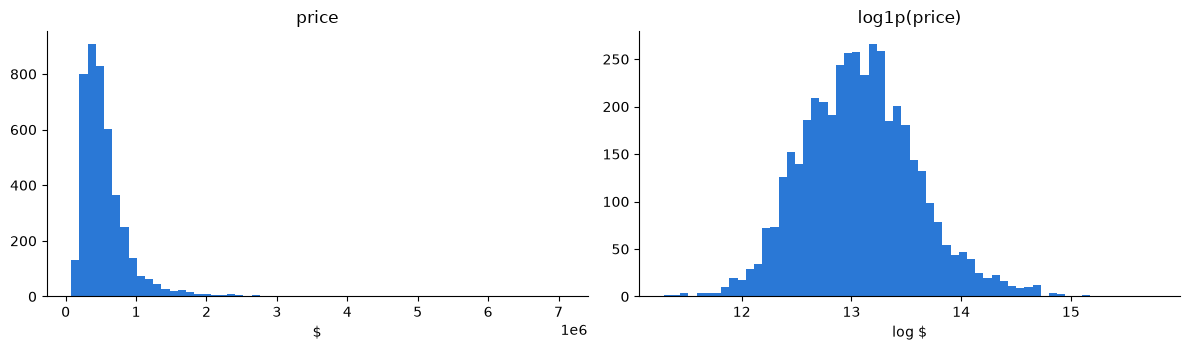

skew before: 4.02   after: 0.34


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(df["price"], bins=60, color="#2a78d6")
axes[0].set_title("price"); axes[0].set_xlabel("$")
axes[1].hist(np.log1p(df["price"]), bins=60, color="#2a78d6")
axes[1].set_title("log1p(price)"); axes[1].set_xlabel("log $")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"skew before: {df['price'].skew():.2f}   after: {np.log1p(df['price']).skew():.2f}")

## 2. Features, and the one that can leak

Everything below is computed **from a single row**. Nothing looks at another row, at a
group mean, or at the target — which is what makes it safe to compute before the train/test
split, and safe to apply to a single house typed into an app.

Two columns are deliberately absent:

- `price_per_sqft`, because it contains the target. Including it produces an R² of 0.99 and
  a model that cannot value a house you have not already sold.
- `sqft_above`, because `sqft_above = sqft_living − sqft_basement` exactly. Perfect
  collinearity makes linear coefficients meaningless.

In [3]:
REFERENCE_YEAR = 2014

def engineer_features(d):
    d = d.copy()
    d["house_age"] = REFERENCE_YEAR - d["yr_built"]

    yr_reno = d.get("yr_renovated", pd.Series(np.nan, index=d.index))
    renovated = yr_reno.notna() & (yr_reno > 0)
    d["was_renovated"] = renovated.astype(int)
    d["years_since_reno"] = np.where(renovated,
                                     REFERENCE_YEAR - yr_reno.fillna(REFERENCE_YEAR),
                                     d["house_age"])

    d["has_basement"] = (d["sqft_basement"] > 0).astype(int)
    d["basement_ratio"] = (d["sqft_basement"] / d["sqft_living"].replace(0, np.nan)).fillna(0)
    d["bath_per_bed"] = (d["bathrooms"] / d["bedrooms"].replace(0, np.nan)).fillna(d["bathrooms"])
    d["sqft_per_room"] = (d["sqft_living"] /
                          (d["bedrooms"].fillna(0) + d["bathrooms"].fillna(0)).replace(0, np.nan)
                          ).fillna(d["sqft_living"])
    d["log_sqft_living"] = np.log1p(d["sqft_living"])
    d["log_sqft_lot"] = np.log1p(d["sqft_lot"])
    return d

NUMERIC = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront",
           "view", "condition", "sqft_basement", "house_age", "was_renovated",
           "years_since_reno", "has_basement", "basement_ratio", "bath_per_bed",
           "sqft_per_room", "log_sqft_living", "log_sqft_lot"]
CATEGORICAL = ["zipcode", "city"]
FEATURES = NUMERIC + CATEGORICAL

data = engineer_features(df)
print(f"{len(FEATURES)} features: {len(NUMERIC)} numeric + {len(CATEGORICAL)} target-encoded")

20 features: 18 numeric + 2 target-encoded


### Target encoding, with two safeguards

`zipcode` has 77 levels and `city` has 43. One-hot encoding them adds 120 sparse columns;
dropping them throws away the strongest signal in the data, because location is what house
prices *are*.

Target encoding replaces the category with the mean price of that category. Done naively it
leaks the answer, so two safeguards:

**Smoothing.** A zip code with three sales should not be trusted like one with 142. Each
category mean is pulled toward the global mean with weight `n / (n + m)`, `m = 20`. This is
credibility weighting from actuarial ratemaking — `Z = n / (n + k)` — and it is the same
defence against thin cells.

**Out-of-fold encoding.** If a row's own price helps compute the mean that becomes that
row's feature, the feature partly contains the answer, the model over-trusts it, and test
performance collapses. During `fit_transform` each training row is encoded from the *other*
folds only.

In [4]:
class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None, smoothing=20.0, n_splits=5, random_state=42):
        self.cols, self.smoothing = cols, smoothing
        self.n_splits, self.random_state = n_splits, random_state

    def _map(self, s, y, prior):
        stats = y.groupby(s).agg(["mean", "count"])
        w = stats["count"] / (stats["count"] + self.smoothing)
        return (w * stats["mean"] + (1 - w) * prior).to_dict()

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(np.asarray(y)).reset_index(drop=True)
        self.feature_names_in_ = list(self.cols or X.columns)
        self.prior_ = float(y.mean())
        self.maps_ = {c: self._map(X[c], y, self.prior_) for c in self.feature_names_in_}
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = pd.DataFrame(index=X.index)
        for c in self.feature_names_in_:
            out[f"{c}_te"] = X[c].map(self.maps_[c]).astype(float).fillna(self.prior_)
        return out.values

    def fit_transform(self, X, y=None, **kw):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(np.asarray(y)).reset_index(drop=True)
        self.fit(X, y)
        oof = pd.DataFrame(index=X.index,
                           columns=[f"{c}_te" for c in self.feature_names_in_], dtype=float)
        for tr, va in KFold(self.n_splits, shuffle=True, random_state=self.random_state).split(X):
            prior = float(y.iloc[tr].mean())
            for c in self.feature_names_in_:
                m = self._map(X[c].iloc[tr], y.iloc[tr], prior)
                oof.loc[va, f"{c}_te"] = X[c].iloc[va].map(m).astype(float).fillna(prior).values
        return oof.values


def build_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("te", Pipeline([("encode", SmoothedTargetEncoder(cols=CATEGORICAL)),
                         ("scale", StandardScaler())]), CATEGORICAL),
    ], remainder="drop", verbose_feature_names_out=False)

OUTPUT_ORDER = NUMERIC + [f"{c}_te" for c in CATEGORICAL]
print("preprocessor: scaling + out-of-fold smoothed target encoding, fitted on TRAIN only")

preprocessor: scaling + out-of-fold smoothed target encoding, fitted on TRAIN only


## 3. The split, and the market segments

The project uses a fixed 80/20 split saved to disk so that every notebook scores on
exactly the same houses. If `split_indices.csv` is in the input it is used; otherwise the
same split is recreated with the same seed.

In [5]:
X, y = data[FEATURES], np.log1p(data["price"])

try:
    split = pd.read_csv(find("split_indices.csv"), index_col="row")["split"]
    if (len(split) != len(data) or not split.index.equals(data.index)
            or not split.isin(["train", "test"]).all()):
        raise ValueError("split_indices.csv must match the data rows and contain only train/test.")
    is_train = split.eq("train").to_numpy()
    print("Using the project's saved split.")
except FileNotFoundError:
    idx_tr, _ = train_test_split(np.arange(len(data)), test_size=0.2, random_state=42)
    is_train = np.zeros(len(data), bool); is_train[idx_tr] = True
    print("split_indices.csv not found - recreated an 80/20 split with seed 42.")

X_train, X_test = X[is_train], X[~is_train]
y_train, y_test = y[is_train], y[~is_train]
price_test = np.expm1(y_test).values
print(f"Train {len(X_train):,}   Test {len(X_test):,}")

Using the project's saved split.
Train 3,476   Test 869


### Four segments, found rather than assumed

Before predicting anything, k-means on nine standardised features splits the market into
four groups. `k = 4` came from the elbow and the silhouette curve agreeing; the names below
are descriptions of the cluster centres, written after looking at them rather than decided
in advance.

They matter later: the model's error is not evenly distributed across them, and a segment
average hides that.

In [6]:
from sklearn.cluster import KMeans

# The same nine features the full project clustered on.
CLUSTER_FEATURES = ["log_sqft_living", "log_sqft_lot", "bedrooms", "bathrooms", "floors",
                    "house_age", "condition", "view", "has_basement"]

km = Pipeline([("scale", StandardScaler()), ("km", KMeans(4, n_init=10, random_state=42))])
raw_labels = km.fit_predict(data[CLUSTER_FEATURES])

prof = (data.assign(c=raw_labels).groupby("c")
        .agg(n=("price", "size"), median_price=("price", "median"),
             sqft=("sqft_living", "median"), age=("house_age", "median"),
             view=("view", "mean")))

# Name the clusters from their centres, by rule rather than by hand. k-means numbers its
# clusters arbitrarily - re-run it on a different machine and cluster 0 becomes cluster 3 -
# so a hard-coded {0: "..."} mapping is a bug waiting to happen.
premium   = prof["view"].idxmax()                                   # the view group
newbuild  = prof.drop(premium)["age"].idxmin()                      # the youngest houses
compact   = prof.drop([premium, newbuild])["sqft"].idxmin()         # the smallest
established = [c for c in prof.index if c not in (premium, newbuild, compact)][0]

NAMES = {premium: "Premium View Property", newbuild: "New-Build Suburban Family",
         compact: "Compact Entry-Level", established: "Established Family Home"}
labels = pd.Series(raw_labels).map(NAMES).values

prof.index = [NAMES[c] for c in prof.index]
prof["share_%"] = (100 * prof["n"] / len(data)).round(1)
prof.round(1)

,n,median_price,sqft,age,view,share_%
New-Build Suburban Family,1579,535000.0,2400.0,13.0,0.0,36.3
Established Family Home,1187,494000.0,2090.0,52.0,0.0,27.3
Compact Entry-Level,1237,335500.0,1250.0,60.0,0.1,28.5
Premium View Property,342,855000.0,2990.0,44.0,2.6,7.9


## 4. Four models, and a baseline that is not zero

A model is only "good" against something. Three references, in increasing order of
difficulty:

- **Zip-code median.** No model at all: predict the median price per square foot of the zip
  code, times the square footage. Any model that cannot beat this has learned nothing that
  a table lookup does not already know.
- **Ridge regression** on the same features, which is the honest linear baseline.
- **Random Forest and Gradient Boosting**, at the settings the full project's grid search
  selected.

In [7]:
def score(y_true_log, y_pred_log, label):
    true_d, pred_d = np.expm1(y_true_log), np.expm1(y_pred_log)
    ape = np.abs(pred_d - true_d) / true_d
    return {"model": label,
            "R2_log": r2_score(y_true_log, y_pred_log),
            "MAE_$": mean_absolute_error(true_d, pred_d),
            "MedAPE_%": 100 * np.median(ape),
            "MAPE_%": 100 * ape.mean(),
            "PPE10_%": 100 * (ape <= 0.10).mean()}

# Baseline 0: the zip-code median price per square foot.
ppsf = (data.loc[is_train, "price"] / data.loc[is_train, "sqft_living"]).groupby(
    data.loc[is_train, "zipcode"]).median()
zip_pred = (data.loc[~is_train, "zipcode"].map(ppsf).fillna(ppsf.median())
            * data.loc[~is_train, "sqft_living"])

rows = [score(y_test, np.log1p(zip_pred.values), "Zip-code median $/sqft")]

models = {
    "Ridge": RidgeCV(alphas=np.logspace(-2, 3, 30)),
    "Random Forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                           random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(learning_rate=0.05, max_depth=3,
                                                   n_estimators=600, random_state=42),
}

fitted = {}
for name, est in models.items():
    pipe = Pipeline([("pre", build_preprocessor()), ("model", est)]).fit(X_train, y_train)
    fitted[name] = pipe
    rows.append(score(y_test, pipe.predict(X_test), name))

table = pd.DataFrame(rows).set_index("model")
table.round(3)

,R2_log,MAE_$,MedAPE_%,MAPE_%,PPE10_%
model,,,,,
Zip-code median $/sqft,0.784,101226.264,13.938,18.016,38.435
Ridge,0.826,104574.000,12.527,16.919,40.276
Random Forest,0.842,88778.750,10.964,15.186,45.800
Gradient Boosting,0.863,82543.233,10.543,14.580,47.871


**Read the MedAPE column, not R².** R² is computed on logged prices, where it flatters
everything: 0.83 and 0.86 sound close, but the median percentage error behind them differs
by two full points — which on a $500,000 house is $10,000.

**PPE10** — the share of houses valued within 10% of what they actually sold for — is the
number a valuation workflow cares about, and it is sobering: even the best model manages it
for slightly under half of houses.

In [8]:
# Freeze the production candidate before reading this hold-out table. Its family and
# hyperparameters were selected by training-only cross-validation in the full project;
# selecting the lowest test score here would make this test set part of model selection.
CHAMPION_NAME = "Gradient Boosting"
best = CHAMPION_NAME
champion = fitted[CHAMPION_NAME]
pred_log = champion.predict(X_test)
pred_price = np.expm1(pred_log)

print(f"Best on median error: {best} at {table.loc[best, 'MedAPE_%']:.2f}%")
print(f"Ridge baseline      : {table.loc['Ridge', 'MedAPE_%']:.2f}%")
print(f"No-model baseline   : {table.loc['Zip-code median $/sqft', 'MedAPE_%']:.2f}%")

Best on median error: Gradient Boosting at 10.54%
Ridge baseline      : 12.53%
No-model baseline   : 13.94%


## 5. Is the winner actually better, or did it get lucky?

Two models differing by 2 percentage points on 869 houses could easily be one model
differing from itself. Two tests on the **paired** absolute percentage errors — same houses,
both models:

- a **Wilcoxon signed-rank test**, which asks whether the differences are systematically
  one-sided;
- a **bootstrap confidence interval** on the difference in median error, which says how
  large the difference plausibly is.

A p-value alone is not enough: with enough houses, a difference of 0.1% would also be
"significant" and would still not matter.

In [9]:
from scipy.stats import wilcoxon

def ape(pred_log):
    return np.abs(np.expm1(pred_log) - price_test) / price_test

a = ape(champion.predict(X_test))
b = ape(fitted["Ridge"].predict(X_test))

diff = 100 * (np.median(a) - np.median(b))
rng = np.random.default_rng(42)
boot = [100 * (np.median(a[i]) - np.median(b[i]))
        for i in (rng.integers(0, len(a), len(a)) for _ in range(2000))]
lo, hi = np.percentile(boot, [2.5, 97.5])
stat, p = wilcoxon(a, b)

print(f"{best} minus Ridge, median APE: {diff:+.2f} percentage points")
print(f"95% bootstrap CI            : [{lo:+.2f}, {hi:+.2f}]")
print(f"Wilcoxon signed-rank p      : {p:.2e}")
print()
print("Real." if hi < 0 and p < 0.05 else "Not distinguishable on this test set.")

Gradient Boosting minus Ridge, median APE: -1.98 percentage points
95% bootstrap CI            : [-3.08, -0.92]
Wilcoxon signed-rank p      : 9.38e-08

Real.


**And against XGBoost?** This condensed notebook does not install XGBoost, so that comparison
lives in the full project ([notebook 09](https://github.com/EsraaMaamoun/real-estate-machine/blob/master/Notebooks/09_model_tuning.ipynb),
section 8), on the same 869 test houses with the same two tests. Tuned XGBoost scores 10.78%
median error against 10.54% for gradient boosting: a gap of −0.24 points, 95% bootstrap CI
[−0.92, +0.40], Wilcoxon p = 0.12. **Not distinguishable.** XGBoost also passes all three IAAO
tests described in section 6, so the tie is broken on engineering grounds: gradient boosting ships
from scikit-learn alone, with no extra dependency in the deployed app.

## 6. The criterion that actually decides it: the IAAO ratio study

The IAAO *Standard on Ratio Studies*, a published mass-appraisal valuation benchmark, does not
judge a valuation model on R². It uses three statistics from the ratio of predicted to actual
price:

| statistic | what it measures | acceptable |
|---|---|---|
| **median ratio** | systematic over- or under-valuation | 0.90 – 1.10 |
| **COD** | consistency — average spread around the median ratio | ≤ 15 |
| **PRD** | vertical equity — are cheap and expensive homes treated alike? | 0.98 – 1.03 |

PRD is the interesting one, and it is a fairness test rather than an accuracy test. A model
can be accurate on average while systematically over-valuing cheap houses and under-valuing
expensive ones — which, in a tax assessment, means poor owners subsidise rich ones. That
failure is invisible in every metric in section 4.

In [10]:
def iaao(pred, actual):
    ratio = pred / actual
    med = np.median(ratio)
    cod = 100 * np.mean(np.abs(ratio - med)) / med
    prd = np.mean(ratio) / (np.sum(pred) / np.sum(actual))
    return med, cod, prd

out = []
for name, pipe in fitted.items():
    med, cod, prd = iaao(np.expm1(pipe.predict(X_test)), price_test)
    out.append({"model": name, "median_ratio": med, "COD": cod, "PRD": prd,
                "ratio OK": "PASS" if 0.90 <= med <= 1.10 else "FAIL",
                "COD OK": "PASS" if 5 <= cod <= 15 else "FAIL",
                "PRD OK": "PASS" if 0.98 <= prd <= 1.03 else "FAIL"})

pd.DataFrame(out).set_index("model").round(3)

,median_ratio,COD,PRD,ratio OK,COD OK,PRD OK
model,,,,,,
Ridge,1.000,16.921,1.011,PASS,FAIL,PASS
Random Forest,1.005,15.105,1.037,PASS,FAIL,FAIL
Gradient Boosting,0.998,14.604,1.030,PASS,PASS,PASS


## 7. Where the model is wrong — by price, and by segment

An average error is a summary, and summaries hide the cases you would actually be sued
over. Two cuts.

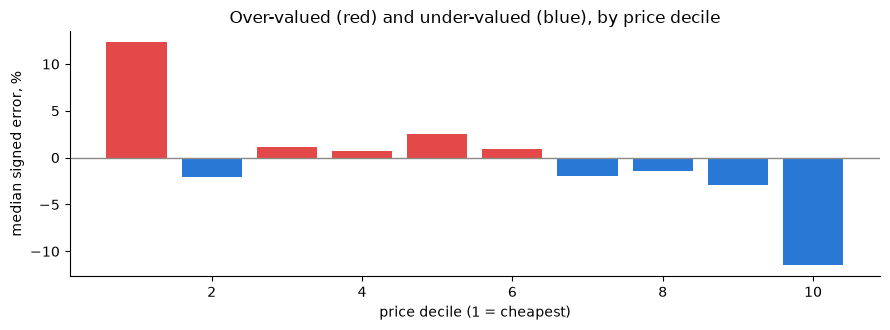

,median_price,median_error,bias
decile,,,
1,223000.0,18.8,12.3
2,295000.0,10.3,-2.1
3,335000.0,9.6,1.1
4,385100.0,10.7,0.7
5,447000.0,9.7,2.5
6,519995.0,10.7,0.9
7,575000.0,8.6,-2.0
8,665000.0,9.1,-1.4
9,819000.0,11.7,-2.9


In [11]:
res = pd.DataFrame({
    "actual": price_test,
    "pred": pred_price,
    "segment": pd.Series(labels)[~is_train].values,
})
res["signed_%"] = 100 * (res["pred"] - res["actual"]) / res["actual"]
res["abs_%"] = res["signed_%"].abs()
res["decile"] = pd.qcut(res["actual"], 10, labels=False) + 1

by_decile = res.groupby("decile").agg(median_price=("actual", "median"),
                                      median_error=("abs_%", "median"),
                                      bias=("signed_%", "median")).round(1)

fig, ax = plt.subplots(figsize=(9, 3.4))
colors = ["#e34948" if b > 0 else "#2a78d6" for b in by_decile["bias"]]
ax.bar(by_decile.index, by_decile["bias"], color=colors)
ax.axhline(0, color="#8a8985", lw=1)
ax.set_xlabel("price decile (1 = cheapest)")
ax.set_ylabel("median signed error, %")
ax.set_title("Over-valued (red) and under-valued (blue), by price decile")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

by_decile

**Both ends are wrong, in opposite directions, and neither is an accident.**

The cheapest decile is over-valued: those houses sit at the edge of the training
distribution, and a squared-error model pulled toward the bulk of the data over-predicts
them.

The top decile is under-valued, and this one is structural: **a tree cannot predict a value
higher than anything it saw in training.** Every leaf is an average of training rows, so the
most expensive houses in the test set are capped by the most expensive houses in the
training set. Boosting improves the *size* of the error at the top and makes the *bias*
worse — which is also what pushes PRD toward the edge of its band in section 6.

If this were going into production, the fix is not a better booster: it is a separate model
for the top decile, or a linear model in the tail where extrapolation is possible.

In [12]:
seg = res.groupby("segment").agg(n=("abs_%", "size"),
                                 median_error=("abs_%", "median"),
                                 median_price=("actual", "median")).round(1)
seg = seg.sort_values("median_error")
seg

,n,median_error,median_price
segment,,,
New-Build Suburban Family,326,9.4,525000.0
Established Family Home,231,9.8,515000.0
Compact Entry-Level,236,10.8,345000.0
Premium View Property,76,17.9,877475.0


One segment is roughly twice as wrong as the others — the small, expensive, high-view group.
It is 8% of the data, it sits at the top of the price range where trees cannot extrapolate,
and it is exactly the kind of property whose value depends on things this dataset does not
record. A single headline error rate would have buried that.

## 8. What the model uses

Two views, because they disagree and the disagreement is informative. Impurity importance
is computed on the training data and is biased toward high-cardinality features; permutation
importance is measured on the **test** set by shuffling one column and watching the score
fall, which is closer to the question you actually care about.

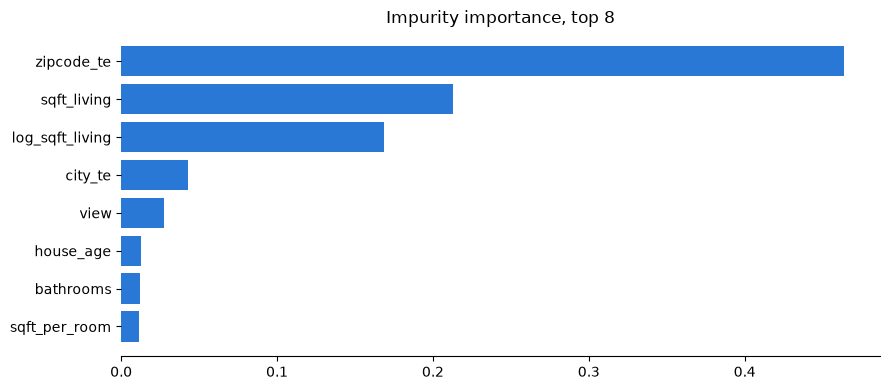

,impurity,permutation
zipcode_te,0.464,0.453
sqft_living,0.213,0.125
log_sqft_living,0.168,0.090
city_te,0.043,0.093
view,0.027,0.034
house_age,0.013,0.013
bathrooms,0.012,0.004
sqft_per_room,0.011,0.002


In [13]:
from sklearn.inspection import permutation_importance

pre = champion.named_steps["pre"]
Z_test = pre.transform(X_test)
imp = pd.Series(champion.named_steps["model"].feature_importances_,
                index=OUTPUT_ORDER).sort_values(ascending=False)

perm = permutation_importance(champion.named_steps["model"], Z_test, y_test,
                              n_repeats=5, random_state=42, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=OUTPUT_ORDER).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
top = imp.head(8)[::-1]
ax.barh(top.index, top.values, color="#2a78d6")
ax.set_title("Impurity importance, top 8")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout(); plt.show()

pd.DataFrame({"impurity": imp.head(8).round(3),
              "permutation": perm_s.reindex(imp.head(8).index).round(3)})

Location dominates, and it is not close. The encoded zip code alone carries more weight than
every structural feature combined — which matches the old "location, location, location"
saying, and is worth checking rather than assuming.

Several features contribute essentially nothing: `floors`, `was_renovated`, `has_basement`,
`bedrooms`. That does not mean bedrooms are irrelevant to a buyer; it means bedrooms carry
no information *once the model already knows the square footage*, which is a statement about
redundancy rather than about houses.

## 9. What this is, and what it is not

**What it does.** Values a house within about 10.5% of its sale price, half the time
(median), inside a measured 10–90 range of −20% / +26%. It passes all three IAAO ratio
tests, which the linear baseline does not.

**What it does not do.**

- Ten weeks of 2014 data: no seasonality, no market trend, and prices more than a decade stale.
- King County, Washington only. It will not transfer.
- No building grade and no coordinates, so location is captured coarsely by zip code.
- 29 waterfront homes in the cleaned dataset — too few for any confident claim.
- It cannot see the inside of a house, the neighbour's extension, or why someone sold in a
  hurry.

**How it should be used.** As a screening tool that puts a defensible range and a written
reason in front of a human, not as a number to quote a client.

---

The full project adds a SHAP-based explanation layer, an LLM that turns the evidence into a
paragraph — with a grounding check that rejects any number it was not given — and a
deployed Streamlit app. Links in the description.